Carreguem les dades

In [1]:
import pandas as pd

# Carreguem el CSV preparat
df = pd.read_csv("../data/df_preparat.csv")



4.3 Comprovació de l'ordre de les categories i perquè surten les dades amb aquesta forma

C:\Users\david\AppData\Local\Temp\ipykernel_19388\1134879422.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  customer_cat = customer_cat.applymap(lambda x: 1 if x > 0 else 0)


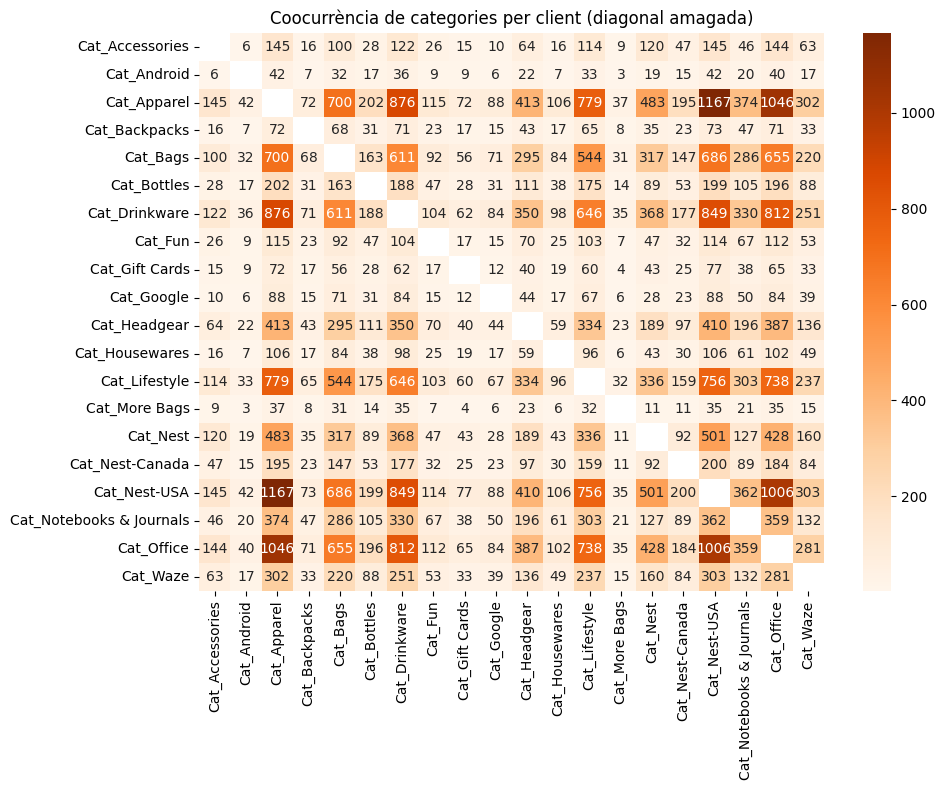

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionem categories
category_cols = [col for col in df.columns if col.startswith('Cat_')]

df_cat_cust = df[['CustomerID'] + category_cols]

# 2. Matriu binària per client i categoria
customer_cat = df_cat_cust.groupby('CustomerID')[category_cols].sum()
customer_cat = customer_cat.applymap(lambda x: 1 if x > 0 else 0)

# 3. Matriu de coocurrència
category_co_matrix_cust = customer_cat.T.dot(customer_cat)

# 4. Eliminem files/columnes buides si n'hi ha
category_co_matrix_cust = category_co_matrix_cust.loc[
    (category_co_matrix_cust.sum(axis=1) > 0),
    (category_co_matrix_cust.sum(axis=0) > 0)
]

# 5. Convertim NaNs a 0 per seguretat
category_co_matrix_cust = category_co_matrix_cust.fillna(0)

# 6. Eliminem visualment la diagonal
co_matrix_visual = category_co_matrix_cust.astype(float).copy()
np.fill_diagonal(co_matrix_visual.values, np.nan)

# 7. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (diagonal amagada)")
plt.tight_layout()
plt.show()


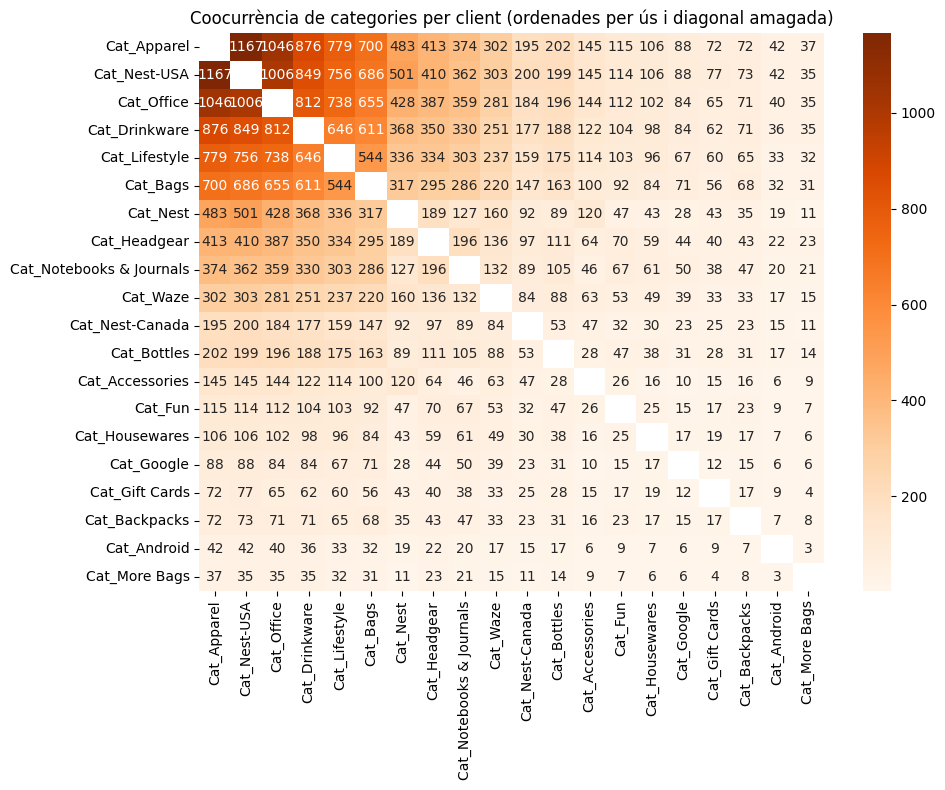

In [3]:
# 1. Ordenem les categories segons el total de compres per categoria
category_order = customer_cat.sum().sort_values(ascending=False).index.tolist()

# 2. Reordenem la matriu de coocurrència segons aquest ordre
co_matrix_visual = category_co_matrix_cust.loc[category_order, category_order].astype(float)

# 3. Amaguem la diagonal
np.fill_diagonal(co_matrix_visual.values, np.nan)

# 4. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (ordenades per ús i diagonal amagada)")
plt.tight_layout()
plt.show()


In [4]:
# Comptem quants clients han comprat almenys una vegada cada categoria
clients_per_category = customer_cat.sum()

# Imprimim el resultat
print("Nombre de clients per categoria:")
print(clients_per_category)


Nombre de clients per categoria:
Cat_Accessories              150
Cat_Android                   42
Cat_Apparel                 1323
Cat_Backpacks                 75
Cat_Bags                     728
Cat_Bottles                  203
Cat_Drinkware                919
Cat_Fun                      118
Cat_Gift Cards                77
Cat_Google                    89
Cat_Headgear                 425
Cat_Housewares               107
Cat_Lifestyle                817
Cat_More Bags                 37
Cat_Nest                     516
Cat_Nest-Canada              205
Cat_Nest-USA                1260
Cat_Notebooks & Journals     383
Cat_Office                  1103
Cat_Waze                     309
dtype: int64


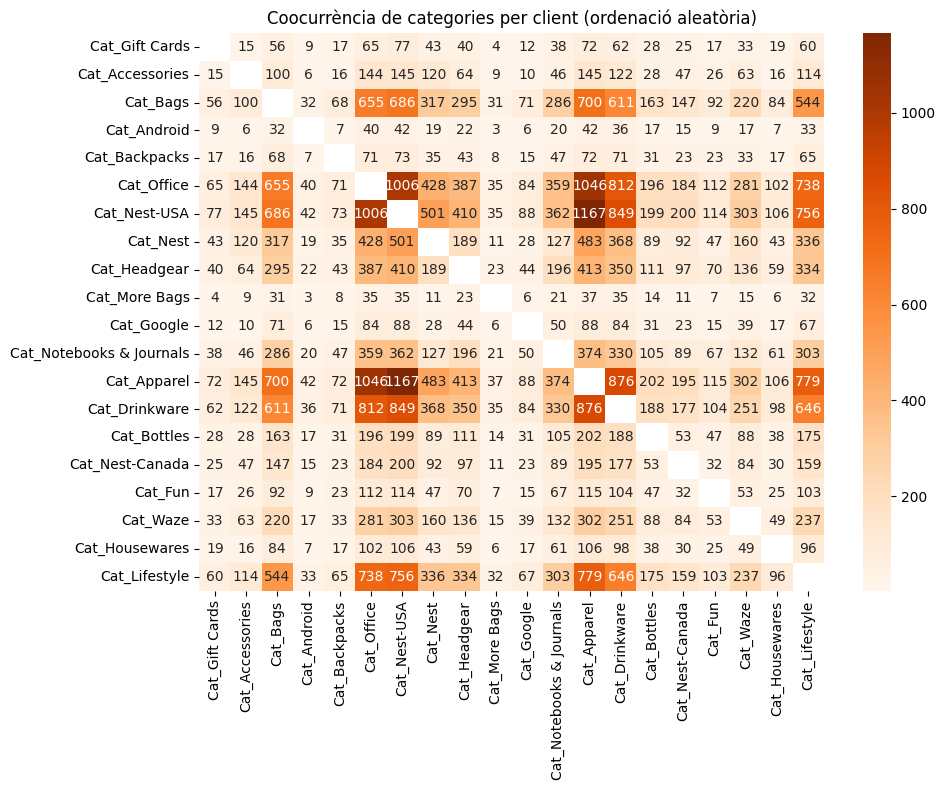

In [5]:
import random

# 1. Llista de categories aleatòriament ordenada
random_order = category_co_matrix_cust.columns.tolist()
random.shuffle(random_order)

# 2. Reordenem la matriu
co_matrix_random = category_co_matrix_cust.loc[random_order, random_order].astype(float)

# 3. Amaguem la diagonal
np.fill_diagonal(co_matrix_random.values, np.nan)

# 4. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_random, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (ordenació aleatòria)")
plt.tight_layout()
plt.show()


Coclustering client-mes

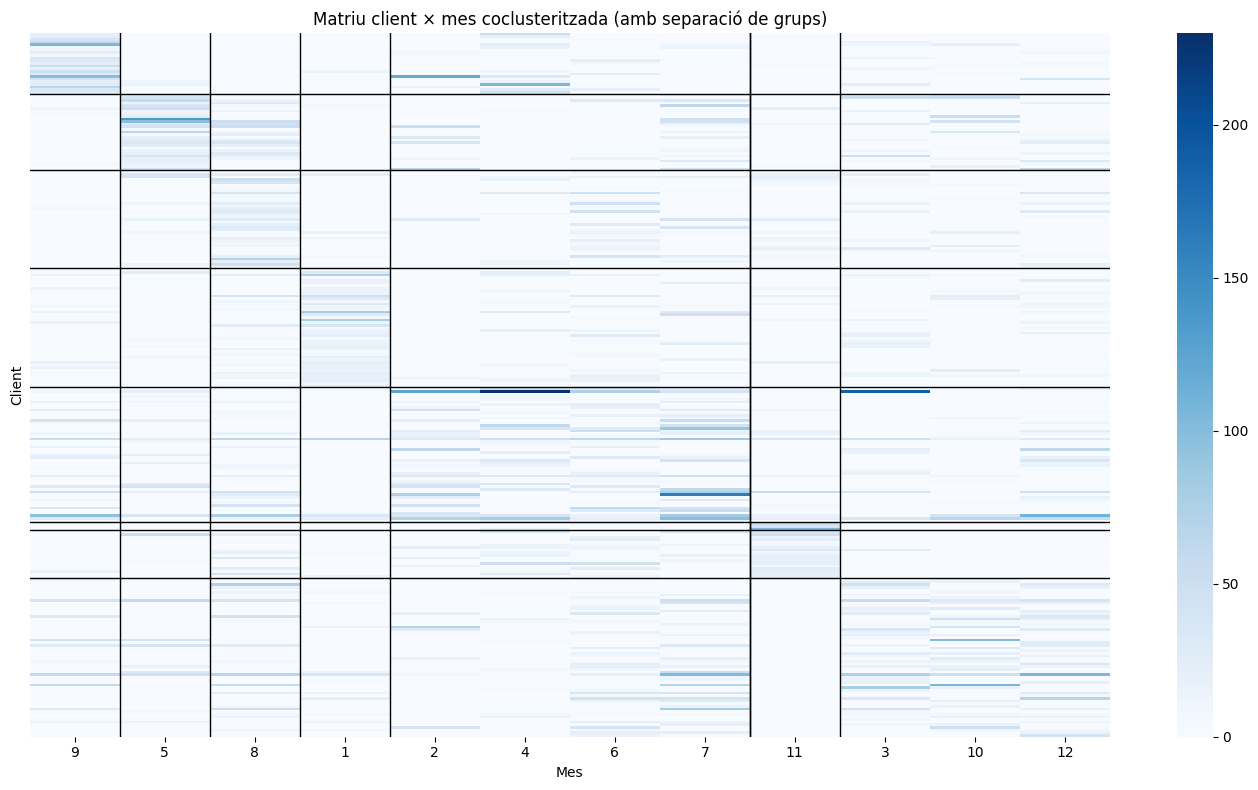

In [6]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "CustomerID"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["CustomerID"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Client_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("../filesRunTime/client_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("../filesRunTime/month_coclusters_client_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Client_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu client × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


Coclustering producte-mes

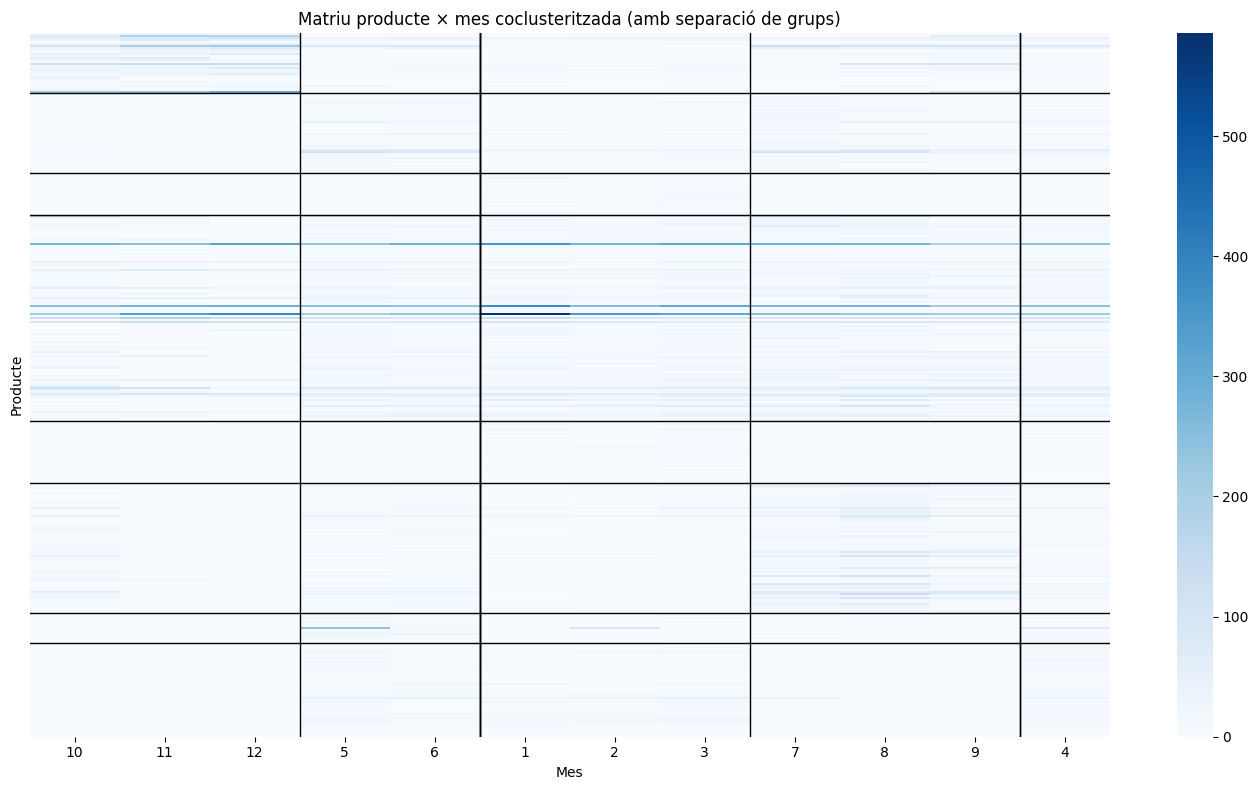

In [7]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "Product_Description"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["Product_Description"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Product_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("../filesRunTime/product_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("../filesRunTime/month_coclusters_product_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Product_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu producte × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Producte")
plt.tight_layout()
plt.show()
